# Method 5: Zero Lattice Paths (AbrikosovTree / RiemannHypothesisProof / POE)

**Ainulindale Engine** — Tier udeo_crypto

Cody's method 5 — trace Content/Public/Private/Hash through the 9-level CD tower. Surfaced the mod4 theorem. Public-key-only scenario at chance.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import importlib.util, math, cmath, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

def load_maths(tier):
    paths = {7: '../../modules/tier7_cosmos/maths.py',
             8: '../../modules/tier8_sedenion/maths.py',
             9: '../../modules/tier9_chem/maths.py',
             'udeo_crypto': '../../modules/udeo_crypto/UDEO_RSA_DEMO.py'}
    spec = importlib.util.spec_from_file_location(f't{tier}', paths[tier])
    m = importlib.util.module_from_spec(spec); spec.loader.exec_module(m)
    return m

OMEGA_ZS = 0.5671432904097838
D_STAR   = 0.24600
GAP      = OMEGA_ZS - D_STAR * math.log(10)
R_H      = 1.0 / math.sqrt(2.0)
RIEMANN_ZEROS = [14.134725, 21.022040, 25.010858, 30.424876, 32.935062,
                 37.586178, 40.918719, 43.327073, 48.005151, 49.773832]
print("Ainulindale notebook ready.")


Ainulindale notebook ready.


In [2]:
m = load_maths('udeo_crypto')
result = m.method5_zero_lattice_paths()
print("Claim:", result['claim'])
print("Confidence:", result['confidence'])


Claim: Method 5 (Zero Lattice paths): trace Content/Public/Private/Hash through the 9-level CD tower; test both the Hash-exposed and public-key-only scenarios.
Confidence: OPEN


## Engine Output

In [3]:
import pprint
pprint.pprint({k: v for k, v in result.items()
               if k not in ('claim', 'confidence', 'latex')}, width=100, depth=3)


{'hash_exposed_scenario': {'caveat': 'Same caveat as Method 4: requires Hash = n+e+d to be exposed '
                                     'somewhere, which requires d to compute in the first place. '
                                     'Not a public-key-only attack.',
                           'confidence': 'ESTABLISHED',
                           'verdict': 'EXACT — Content+Public-Hash = -d exactly in every key '
                                      '(plain integer algebra)'},
 'per_key': [{'content_path': {...},
              'content_plus_public_minus_hash': -103,
              'control_mean_dist_deg': 93.103,
              'd': 103,
              'e': 7,
              'exact_recovery_if_hash_known': True,
              'hash_n_plus_e_plus_d': 253,
              'hash_path': {...},
              'n': 143,
              'private_path': {...},
              'public_path': {...},
              'true_d_dist_to_public_path_deg': 0.0,
              'true_d_percentile_vs_controls_pubke

## Mathematical Foundation

$$\text{LaTeX: }\quad \varphi_k=\text{base}(k)+q\cdot90^\circ\pm22.5^\circ$$

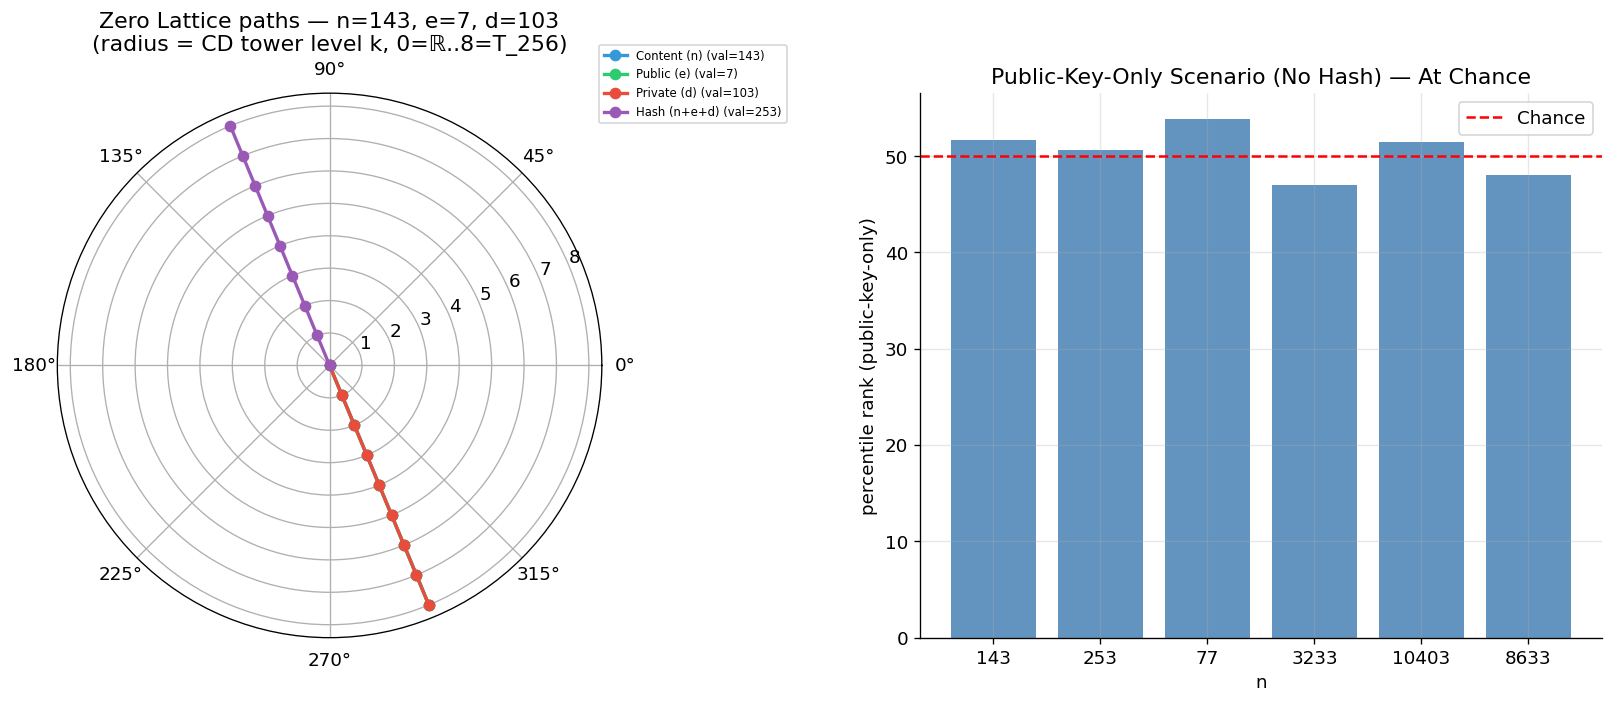

Hash-exposed scenario: EXACT — Content+Public-Hash = -d exactly in every key (plain integer algebra)
Public-key-only scenario: AT CHANCE — path alone (n,e only) does not single out d


In [4]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': 'polar'})
row = result['per_key'][0]
labels_paths = [('content_path', '#3498DB'), ('public_path', '#2ECC71'),
                ('private_path', '#E74C3C'), ('hash_path', '#9B59B6')]

ax = axes[0]
for key, color in labels_paths:
    p = row[key]
    thetas = [math.radians(lv['phi_deg']) for lv in p['levels']]
    radii  = [lv['k'] for lv in p['levels']]
    ax.plot(thetas, radii, 'o-', color=color, label=f"{p['label']} (val={p['value']})", lw=2, ms=6)
ax.set_title(f"Zero Lattice paths — n={row['n']}, e={row['e']}, d={row['d']}\n(radius = CD tower level k, 0=ℝ..8=T_256)")
ax.legend(fontsize=7, loc='upper right', bbox_to_anchor=(1.35, 1.1))

# Right: percentile ranks across all 6 keys, public-key-only scenario
ax2 = axes[1]
ax2.remove()
ax2 = fig.add_subplot(1, 2, 2)
rows_all = result['per_key']
ns_all = [str(r['n']) for r in rows_all]
ranks = [r['true_d_percentile_vs_controls_pubkey_only'] for r in rows_all]
ax2.bar(ns_all, ranks, color='steelblue', alpha=0.85)
ax2.axhline(50, color='r', ls='--', label='Chance')
ax2.set_xlabel('n'); ax2.set_ylabel('percentile rank (public-key-only)')
ax2.set_title('Public-Key-Only Scenario (No Hash) — At Chance')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('Hash-exposed scenario:', result['hash_exposed_scenario']['verdict'])
print('Public-key-only scenario:', result['public_key_only_scenario']['verdict'])


## Ainulindale Reading

**Confidence:** `{}'.format(result.get('confidence',''))`

Run `result.keys()` to explore the full engine output.

In [5]:
print('Engine keys:', list(result.keys()))

Engine keys: ['claim', 'per_key', 'hash_exposed_scenario', 'public_key_only_scenario', 'confidence']
